# Time Series Analysis: NJ Census ACS Data
## State and County Level Trends

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
import duckdb
import pandas as pd


# Connect to DuckDB database in read-only mode
db_path = '../data/db/nj_pipeline.duckdb'
conn = duckdb.connect(db_path, read_only=True)

# Load all census data (all years)
df = conn.execute("SELECT * FROM census_acs").df()

# Continue with your analysis...
print(df.head())

conn.close()

print(f"Years available: {sorted(df['acs_year'].unique())}")
print(f"Geo types: {df['geo_type'].unique()}")

     geoid                                NAME geo_type state_fips place_fips  \
0  3412580         Chester borough, New Jersey    place         34      12580   
1  3475620       Ventnor City city, New Jersey    place         34      75620   
2  3448480  Mountain Lakes borough, New Jersey    place         34      48480   
3  3407360        Brass Castle CDP, New Jersey    place         34      07360   
4  3476010              Villas CDP, New Jersey    place         34      76010   

   zcta  acs_year  pop_total  age_median  race_white  ...  \
0  None      2012       1558        41.4        1381  ...   
1  None      2012      10785        45.9        8329  ...   
2  None      2012       4206        43.4        3723  ...   
3  None      2012       1559        46.1        1550  ...   
4  None      2012       9410        38.8        8749  ...   

   unemployment_rate_acs  pct_bachelors_plus  homeownership_rate  \
0                   7.28               54.05               74.87   
1         

## 1. State-Level Time Series
### Aggregate all places to get state-level trends

In [5]:
# Filter to places only and aggregate to state level
places_df = df[df['geo_type'] == 'place'].copy()

# Aggregate to state level by year
state_metrics = {
    'pop_total': 'sum',
    'age_median': 'mean',
    'income_median_hh': 'median',
    'income_per_capita': 'median',
    'poverty_rate': 'mean',
    'home_value_median': 'median',
    'gross_rent_median': 'median',
    'homeownership_rate': 'mean',
    'pct_bachelors_plus': 'mean',
    'unemployment_rate_acs': 'mean',
    'avg_commute_minutes': 'mean',
    'pct_transit_commute': 'mean',
    'pct_wfh': 'mean',
    'diversity_index': 'mean',
    'gini_index': 'mean',
}

state_df = places_df.groupby('acs_year').agg(state_metrics).reset_index()
state_df = state_df.sort_values('acs_year')

print(f"State-level aggregation complete: {len(state_df)} years")
state_df.head()

,acs_year,pop_total,age_median,income_median_hh,income_per_capita,poverty_rate,home_value_median,gross_rent_median,homeownership_rate,pct_bachelors_plus,unemployment_rate_acs,avg_commute_minutes,pct_transit_commute,pct_wfh,diversity_index,gini_index
0,2012,5266695,42.764391,74722.0,35606.0,7.707426,323900.0,1227.0,73.490496,35.705460,9.211827,29.873055,6.230037,4.207652,0.248662,0.402012
1,2013,5303265,43.159779,75385.5,35303.0,7.914254,313600.0,1238.0,73.228619,36.118692,9.902615,29.820833,6.228324,4.187017,0.256492,0.405066
2,2014,5329988,43.369188,74602.0,36530.0,8.110718,302300.0,1254.0,72.905120,36.520792,9.378785,30.055303,6.272044,4.215580,0.260268,0.405845
3,2015,5354828,43.368266,75536.0,35963.0,8.189134,295750.0,1268.0,72.022081,36.841289,8.458637,30.322917,6.337698,4.414899,0.262121,0.407190
4,2016,5364575,43.673985,76531.5,36944.0,8.289046,292100.0,1305.0,71.851156,37.547706,7.470295,30.493333,6.499816,4.680571,0.258673,0.410689


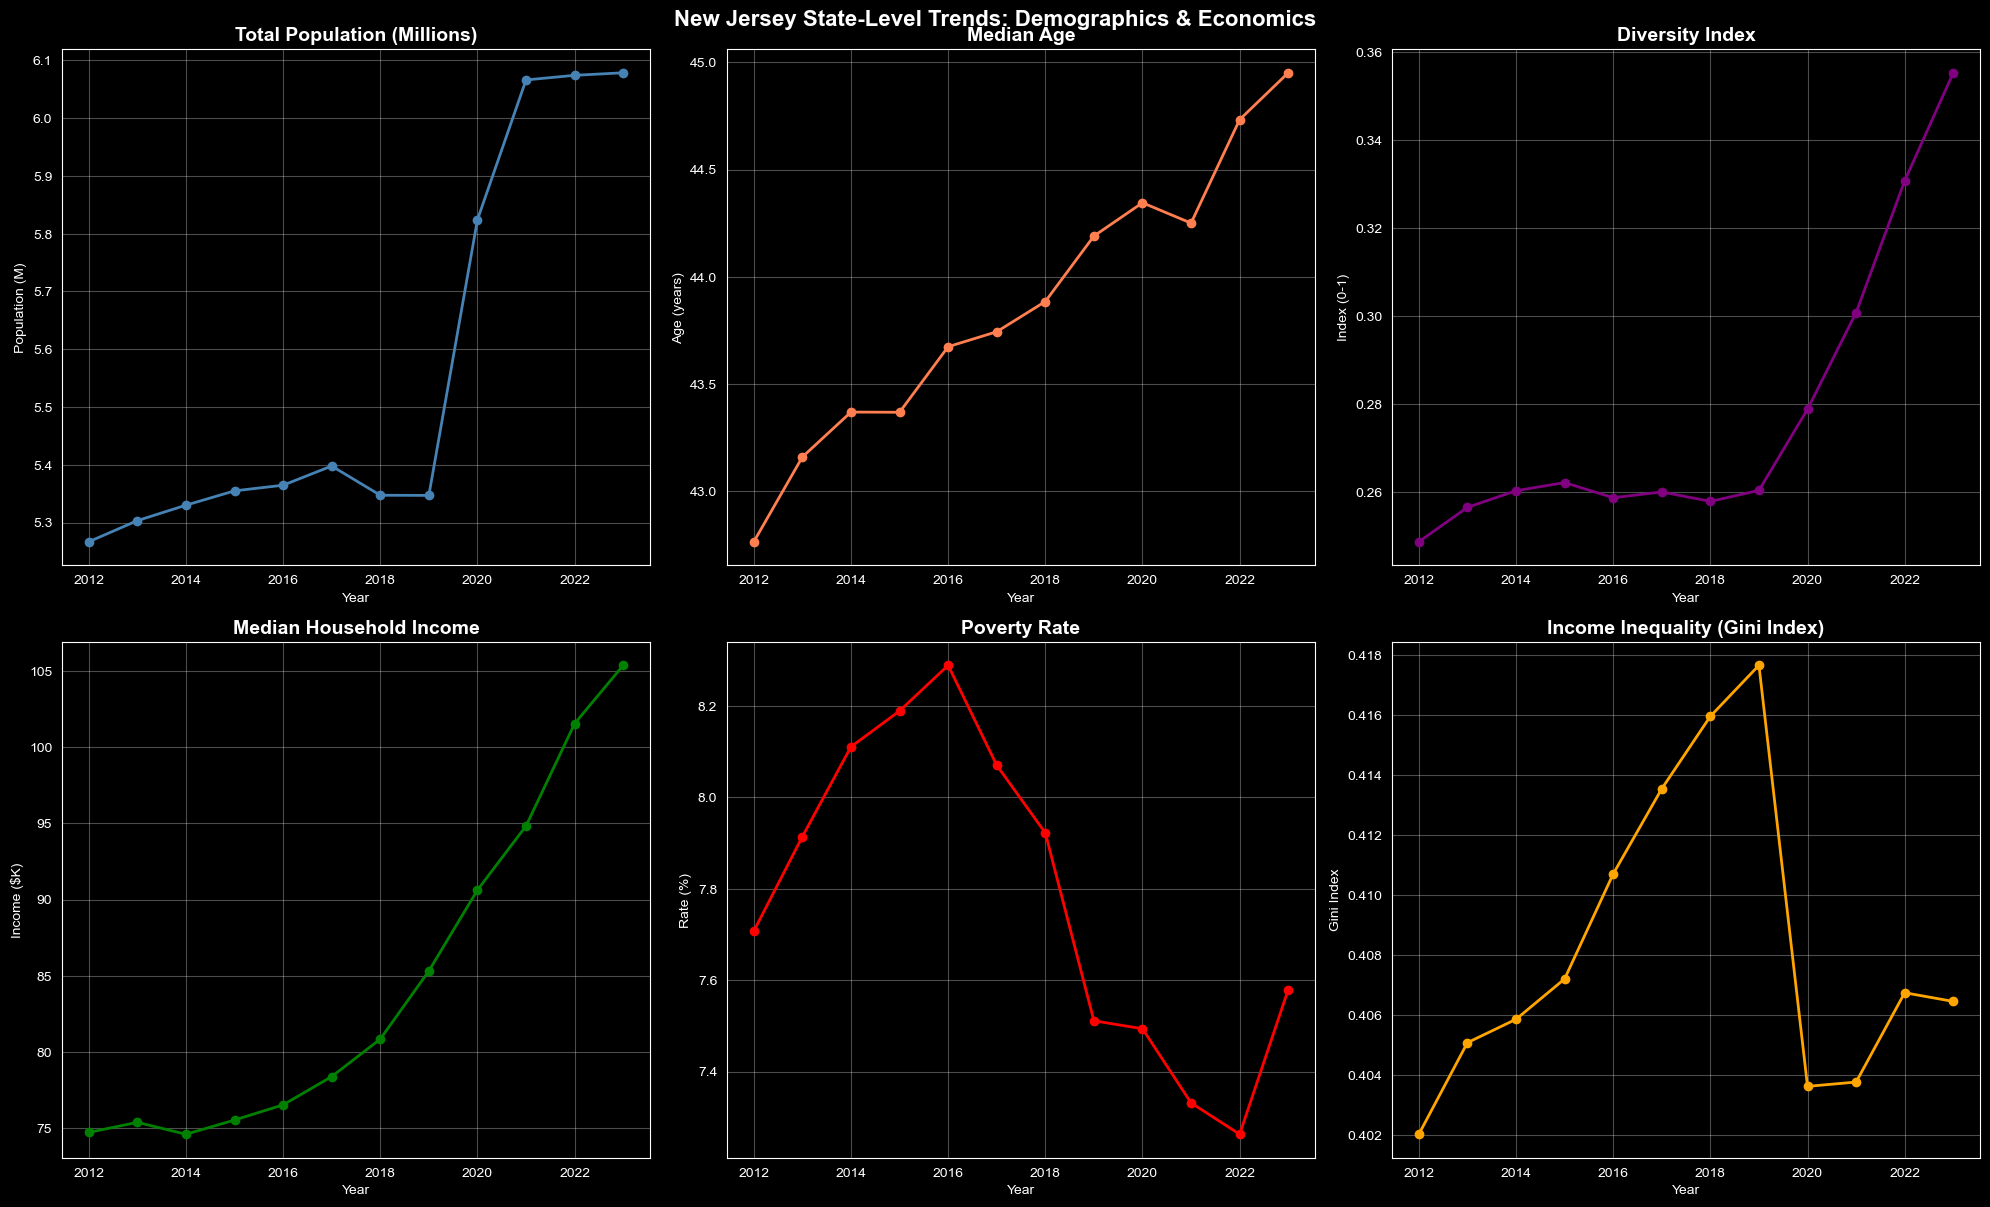

In [8]:
# State-Level Time Series: Demographics & Economics
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# Population
axes[0, 0].plot(state_df['acs_year'], state_df['pop_total']/1e6, marker='o', linewidth=2, color='steelblue')
axes[0, 0].set_title('Total Population (Millions)', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Year')
axes[0, 0].set_ylabel('Population (M)')
axes[0, 0].grid(alpha=0.3)

# Median Age
axes[0, 1].plot(state_df['acs_year'], state_df['age_median'], marker='o', linewidth=2, color='coral')
axes[0, 1].set_title('Median Age', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Year')
axes[0, 1].set_ylabel('Age (years)')
axes[0, 1].grid(alpha=0.3)

# Diversity Index
axes[0, 2].plot(state_df['acs_year'], state_df['diversity_index'], marker='o', linewidth=2, color='purple')
axes[0, 2].set_title('Diversity Index', fontsize=14, fontweight='bold')
axes[0, 2].set_xlabel('Year')
axes[0, 2].set_ylabel('Index (0-1)')
axes[0, 2].grid(alpha=0.3)

# Median Household Income
axes[1, 0].plot(state_df['acs_year'], state_df['income_median_hh']/1000, marker='o', linewidth=2, color='green')
axes[1, 0].set_title('Median Household Income', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Year')
axes[1, 0].set_ylabel('Income ($K)')
axes[1, 0].grid(alpha=0.3)

# Poverty Rate
axes[1, 1].plot(state_df['acs_year'], state_df['poverty_rate'], marker='o', linewidth=2, color='red')
axes[1, 1].set_title('Poverty Rate', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Year')
axes[1, 1].set_ylabel('Rate (%)')
axes[1, 1].grid(alpha=0.3)

# Gini Index (Inequality)
axes[1, 2].plot(state_df['acs_year'], state_df['gini_index'], marker='o', linewidth=2, color='orange')
axes[1, 2].set_title('Income Inequality (Gini Index)', fontsize=14, fontweight='bold')
axes[1, 2].set_xlabel('Year')
axes[1, 2].set_ylabel('Gini Index')
axes[1, 2].grid(alpha=0.3)

plt.tight_layout()
plt.suptitle('New Jersey State-Level Trends: Demographics & Economics', fontsize=16, fontweight='bold', y=1.002)
plt.show()

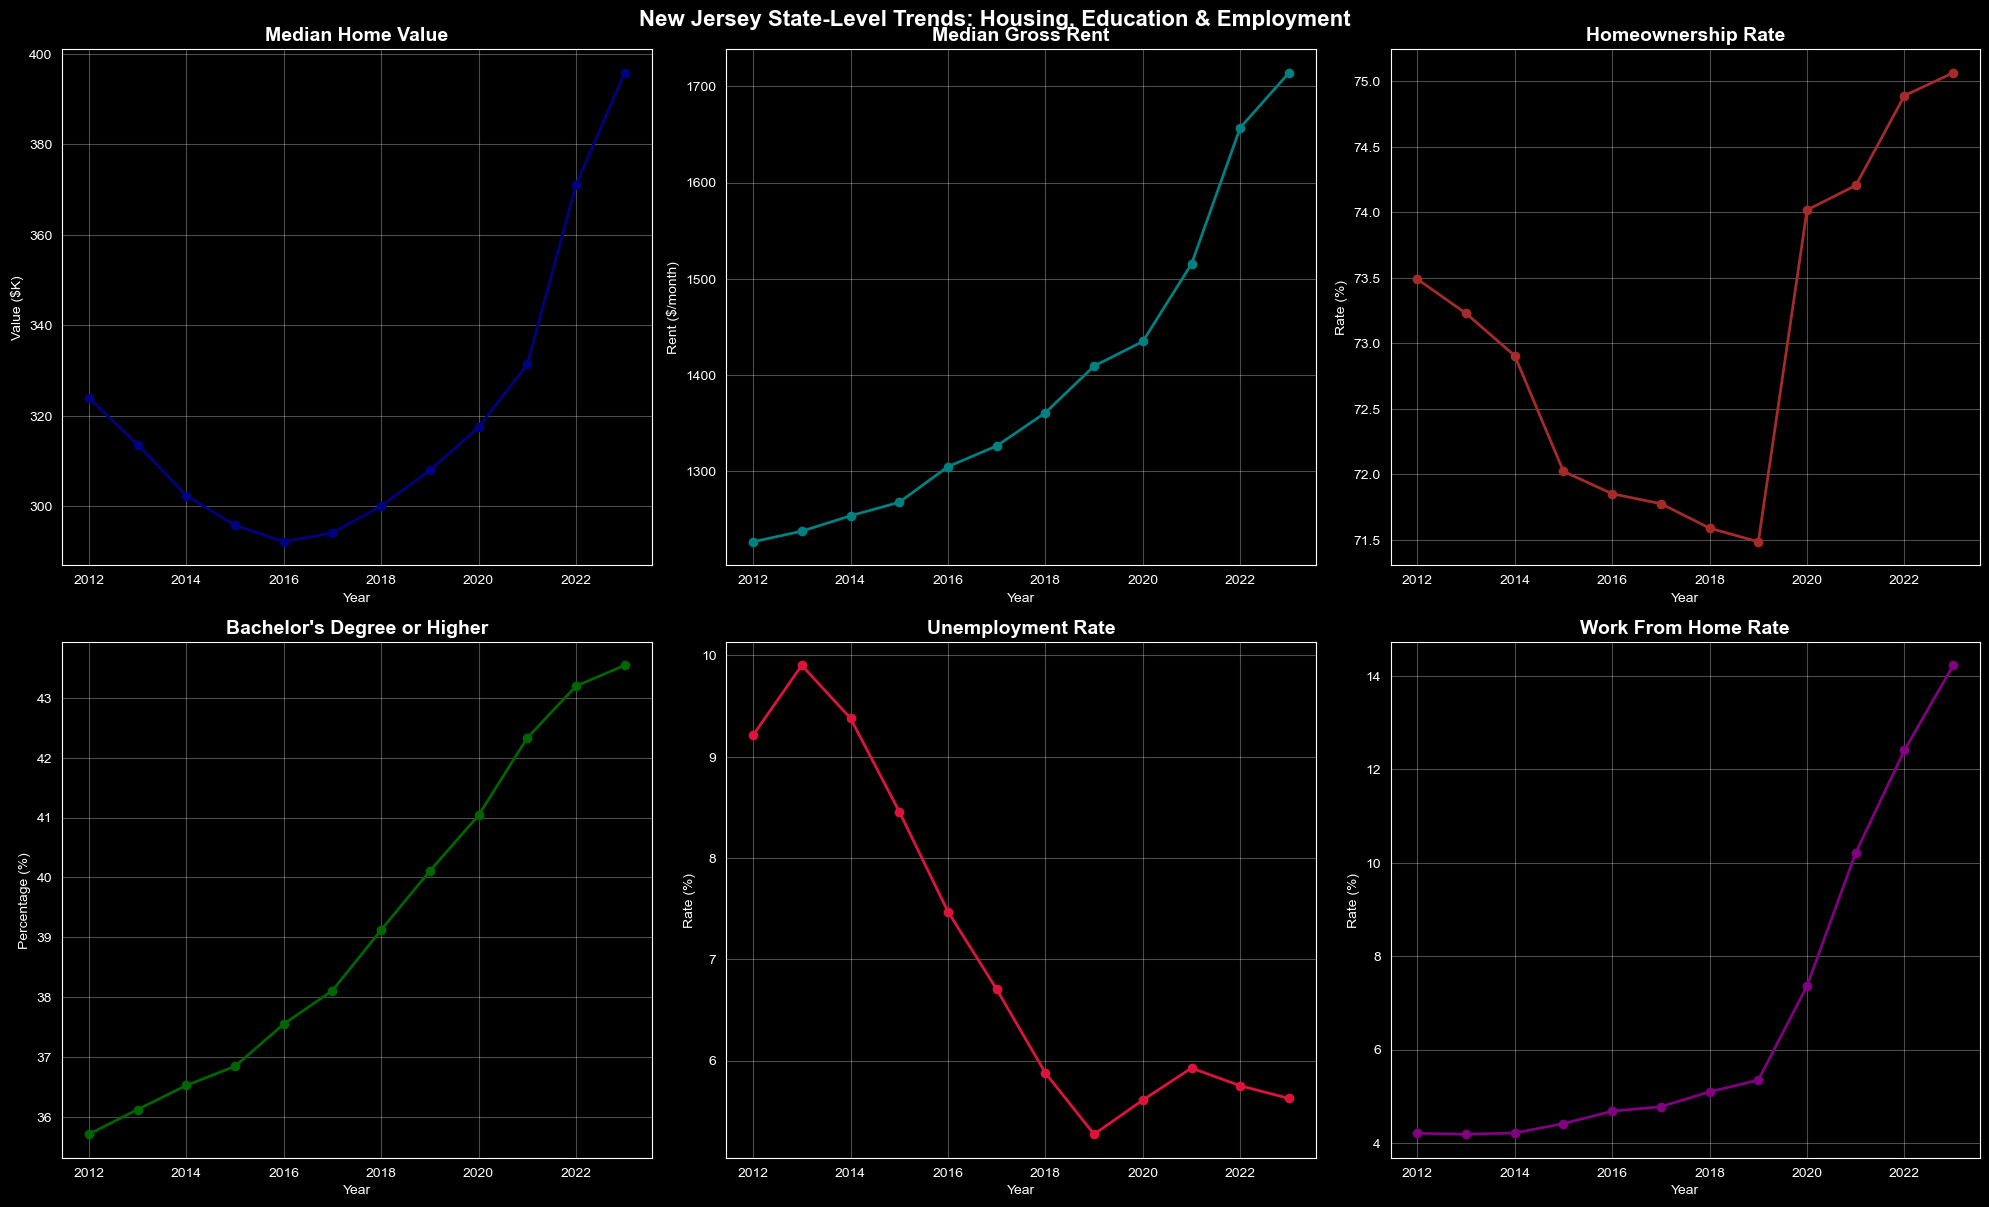

In [9]:
# State-Level Time Series: Housing & Employment
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# Median Home Value
axes[0, 0].plot(state_df['acs_year'], state_df['home_value_median']/1000, marker='o', linewidth=2, color='navy')
axes[0, 0].set_title('Median Home Value', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Year')
axes[0, 0].set_ylabel('Value ($K)')
axes[0, 0].grid(alpha=0.3)

# Median Rent
axes[0, 1].plot(state_df['acs_year'], state_df['gross_rent_median'], marker='o', linewidth=2, color='teal')
axes[0, 1].set_title('Median Gross Rent', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Year')
axes[0, 1].set_ylabel('Rent ($/month)')
axes[0, 1].grid(alpha=0.3)

# Homeownership Rate
axes[0, 2].plot(state_df['acs_year'], state_df['homeownership_rate'], marker='o', linewidth=2, color='brown')
axes[0, 2].set_title('Homeownership Rate', fontsize=14, fontweight='bold')
axes[0, 2].set_xlabel('Year')
axes[0, 2].set_ylabel('Rate (%)')
axes[0, 2].grid(alpha=0.3)

# Bachelor's Degree+
axes[1, 0].plot(state_df['acs_year'], state_df['pct_bachelors_plus'], marker='o', linewidth=2, color='darkgreen')
axes[1, 0].set_title("Bachelor's Degree or Higher", fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Year')
axes[1, 0].set_ylabel('Percentage (%)')
axes[1, 0].grid(alpha=0.3)

# Unemployment Rate
axes[1, 1].plot(state_df['acs_year'], state_df['unemployment_rate_acs'], marker='o', linewidth=2, color='crimson')
axes[1, 1].set_title('Unemployment Rate', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Year')
axes[1, 1].set_ylabel('Rate (%)')
axes[1, 1].grid(alpha=0.3)

# Work From Home
axes[1, 2].plot(state_df['acs_year'], state_df['pct_wfh'], marker='o', linewidth=2, color='purple')
axes[1, 2].set_title('Work From Home Rate', fontsize=14, fontweight='bold')
axes[1, 2].set_xlabel('Year')
axes[1, 2].set_ylabel('Rate (%)')
axes[1, 2].grid(alpha=0.3)

plt.tight_layout()
plt.suptitle('New Jersey State-Level Trends: Housing, Education & Employment', fontsize=16, fontweight='bold', y=1.002)
plt.show()

## 2. County-Level Time Series
### Extract county from place names and analyze trends

In [10]:
# Extract county from place names (format: "Place name, County, New Jersey")
# Note: This is approximate as census places don't always map to counties perfectly
# For proper county analysis, we would need county-level data

# Load NJ county names
nj_counties = [
    'Atlantic', 'Bergen', 'Burlington', 'Camden', 'Cape May', 'Cumberland',
    'Essex', 'Gloucester', 'Hudson', 'Hunterdon', 'Mercer', 'Middlesex',
    'Monmouth', 'Morris', 'Ocean', 'Passaic', 'Salem', 'Somerset',
    'Sussex', 'Union', 'Warren'
]

# Try to extract county from NAME field
def extract_county(name):
    for county in nj_counties:
        if county in name:
            return county
    return 'Unknown'

places_df['county'] = places_df['NAME'].apply(extract_county)

print("Counties identified:")
print(places_df['county'].value_counts())

Counties identified:
county
Unknown       6746
Ocean           68
Cape May        60
Monmouth        36
Union           28
Morris          28
Essex           24
Atlantic        24
Warren          16
Gloucester      12
Camden          12
Salem           12
Sussex          12
Burlington      12
Middlesex       12
Passaic         12
Somerset        12
Mercer          12
Bergen          12
Cumberland      12
Name: count, dtype: int64


In [11]:
# Aggregate by county and year for major counties
major_counties = ['Bergen', 'Essex', 'Hudson', 'Middlesex', 'Monmouth', 'Morris', 'Passaic', 'Union']

county_df = places_df[places_df['county'].isin(major_counties)].groupby(['county', 'acs_year']).agg({
    'pop_total': 'sum',
    'income_median_hh': 'median',
    'poverty_rate': 'mean',
    'home_value_median': 'median',
    'unemployment_rate_acs': 'mean',
    'pct_bachelors_plus': 'mean',
    'pct_wfh': 'mean',
    'diversity_index': 'mean',
}).reset_index()

print(f"County aggregation complete: {len(county_df)} county-year records")
county_df.head(10)

,county,acs_year,pop_total,income_median_hh,poverty_rate,home_value_median,unemployment_rate_acs,pct_bachelors_plus,pct_wfh,diversity_index
0,Bergen,2012,26774,81141.0,7.60,359500.0,6.77,39.06,2.50,0.5798
1,Bergen,2013,26933,79813.0,8.56,348600.0,8.02,39.85,2.63,0.6054
2,Bergen,2014,27157,80365.0,8.89,341400.0,7.25,36.80,2.96,0.6227
3,Bergen,2015,27339,79000.0,7.58,337000.0,6.38,37.25,2.84,0.6406
4,Bergen,2016,27513,81042.0,6.76,332700.0,5.66,41.23,3.59,0.6210
5,Bergen,2017,27694,90962.0,5.91,344500.0,4.47,42.17,3.74,0.6008
6,Bergen,2018,27372,96713.0,5.49,348400.0,3.57,42.63,3.53,0.5588
7,Bergen,2019,27373,96335.0,6.71,358200.0,3.84,44.27,3.22,0.5295
8,Bergen,2020,27375,102724.0,5.95,369500.0,5.45,46.24,4.11,0.5467
9,Bergen,2021,28282,111851.0,5.78,386900.0,6.12,45.77,5.29,0.5707


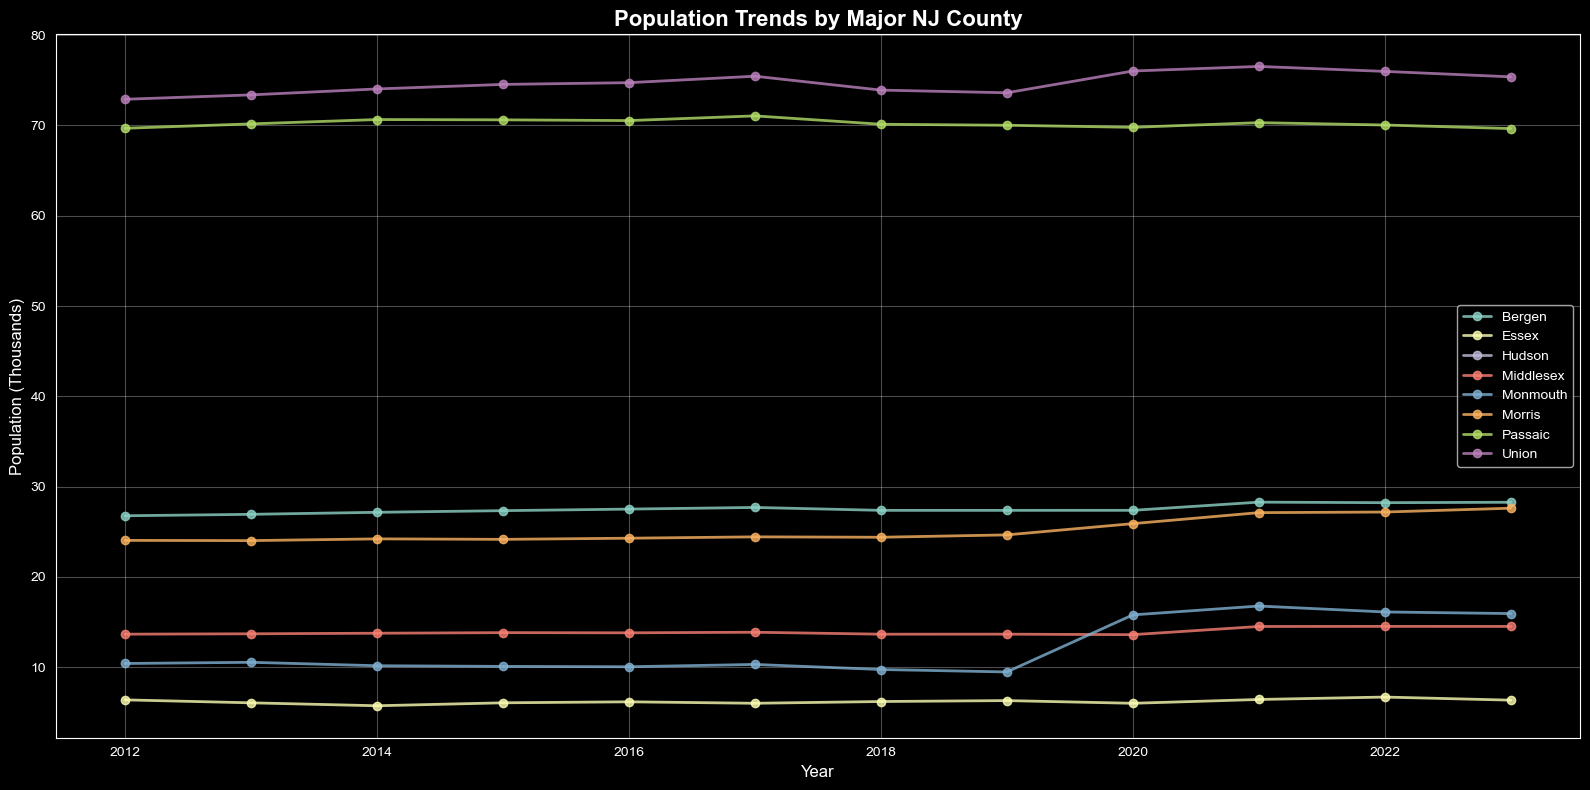

In [13]:
# County Comparison: Population Trends
fig, ax = plt.subplots(figsize=(16, 8))

for county in major_counties:
    county_data = county_df[county_df['county'] == county]
    ax.plot(county_data['acs_year'], county_data['pop_total']/1000, 
            marker='o', linewidth=2, label=county, alpha=0.8)

ax.set_title('Population Trends by Major NJ County', fontsize=16, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Population (Thousands)', fontsize=12)
ax.legend(loc='best', fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

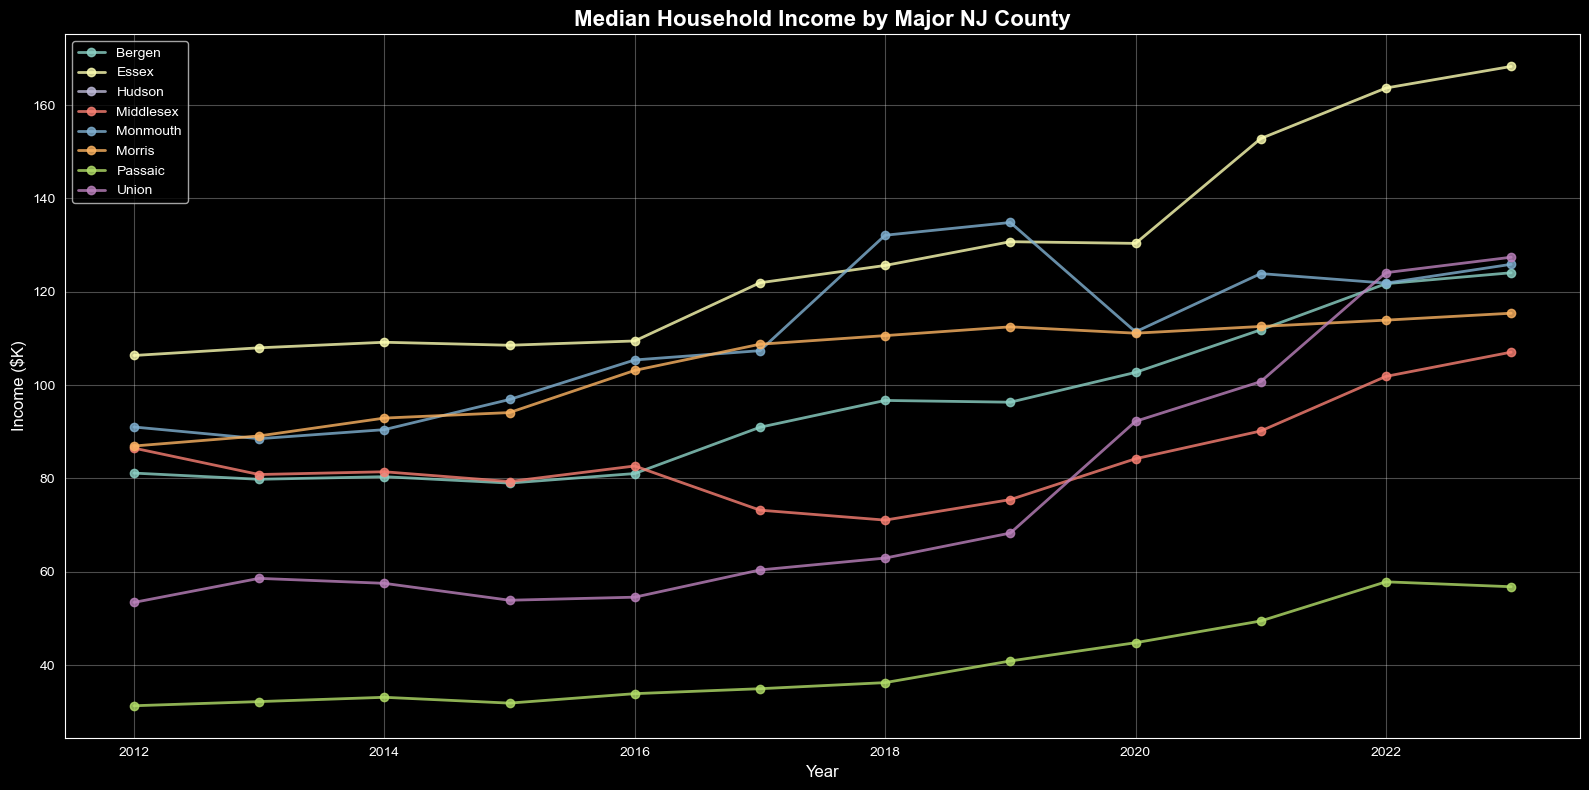

In [14]:
# County Comparison: Median Household Income
fig, ax = plt.subplots(figsize=(16, 8))

for county in major_counties:
    county_data = county_df[county_df['county'] == county]
    ax.plot(county_data['acs_year'], county_data['income_median_hh']/1000, 
            marker='o', linewidth=2, label=county, alpha=0.8)

ax.set_title('Median Household Income by Major NJ County', fontsize=16, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Income ($K)', fontsize=12)
ax.legend(loc='best', fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

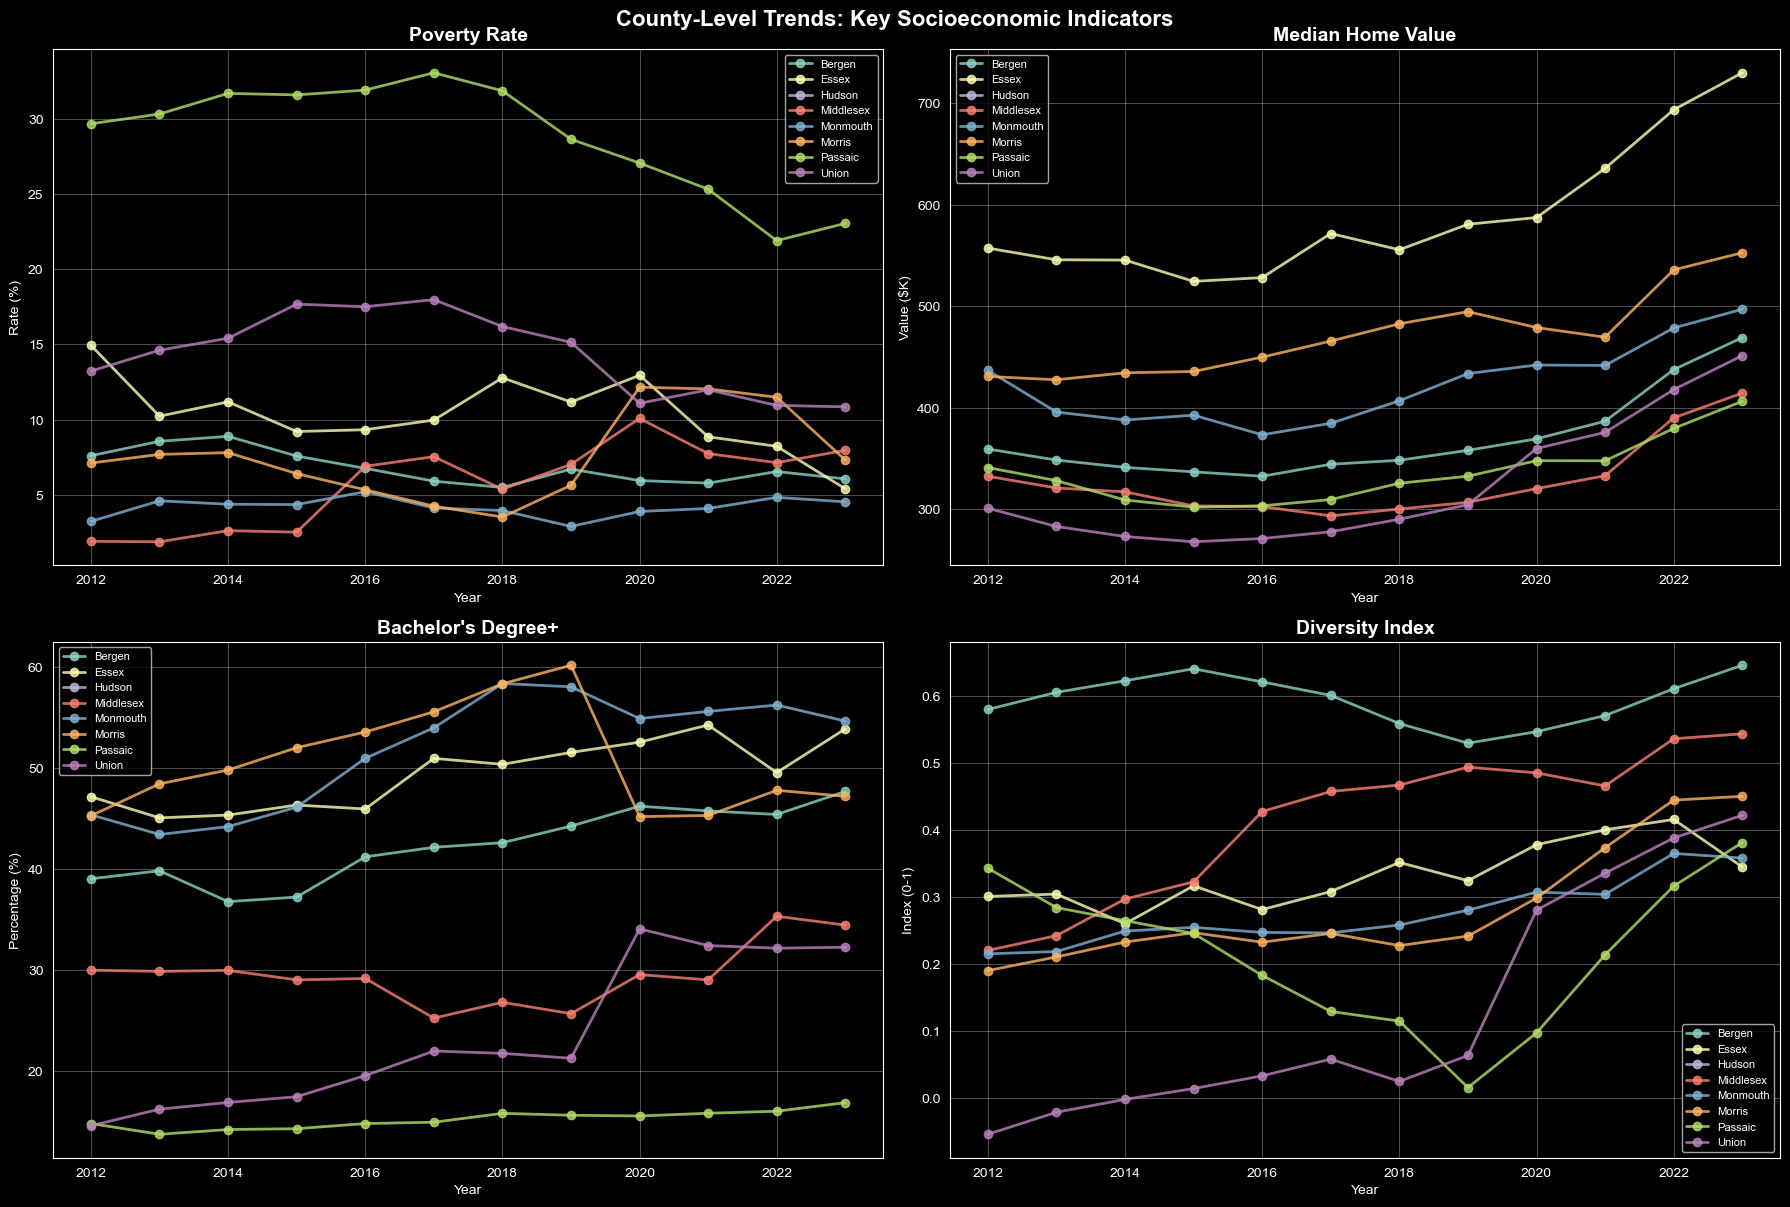

In [15]:
# County Comparison: Multiple Metrics
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Poverty Rate
for county in major_counties:
    county_data = county_df[county_df['county'] == county]
    axes[0, 0].plot(county_data['acs_year'], county_data['poverty_rate'], 
                    marker='o', linewidth=2, label=county, alpha=0.8)
axes[0, 0].set_title('Poverty Rate', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Year')
axes[0, 0].set_ylabel('Rate (%)')
axes[0, 0].legend(loc='best', fontsize=8)
axes[0, 0].grid(alpha=0.3)

# Home Values
for county in major_counties:
    county_data = county_df[county_df['county'] == county]
    axes[0, 1].plot(county_data['acs_year'], county_data['home_value_median']/1000, 
                    marker='o', linewidth=2, label=county, alpha=0.8)
axes[0, 1].set_title('Median Home Value', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Year')
axes[0, 1].set_ylabel('Value ($K)')
axes[0, 1].legend(loc='best', fontsize=8)
axes[0, 1].grid(alpha=0.3)

# Education
for county in major_counties:
    county_data = county_df[county_df['county'] == county]
    axes[1, 0].plot(county_data['acs_year'], county_data['pct_bachelors_plus'], 
                    marker='o', linewidth=2, label=county, alpha=0.8)
axes[1, 0].set_title("Bachelor's Degree+", fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Year')
axes[1, 0].set_ylabel('Percentage (%)')
axes[1, 0].legend(loc='best', fontsize=8)
axes[1, 0].grid(alpha=0.3)

# Diversity
for county in major_counties:
    county_data = county_df[county_df['county'] == county]
    axes[1, 1].plot(county_data['acs_year'], county_data['diversity_index'], 
                    marker='o', linewidth=2, label=county, alpha=0.8)
axes[1, 1].set_title('Diversity Index', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Year')
axes[1, 1].set_ylabel('Index (0-1)')
axes[1, 1].legend(loc='best', fontsize=8)
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.suptitle('County-Level Trends: Key Socioeconomic Indicators', fontsize=16, fontweight='bold', y=1.002)
plt.show()

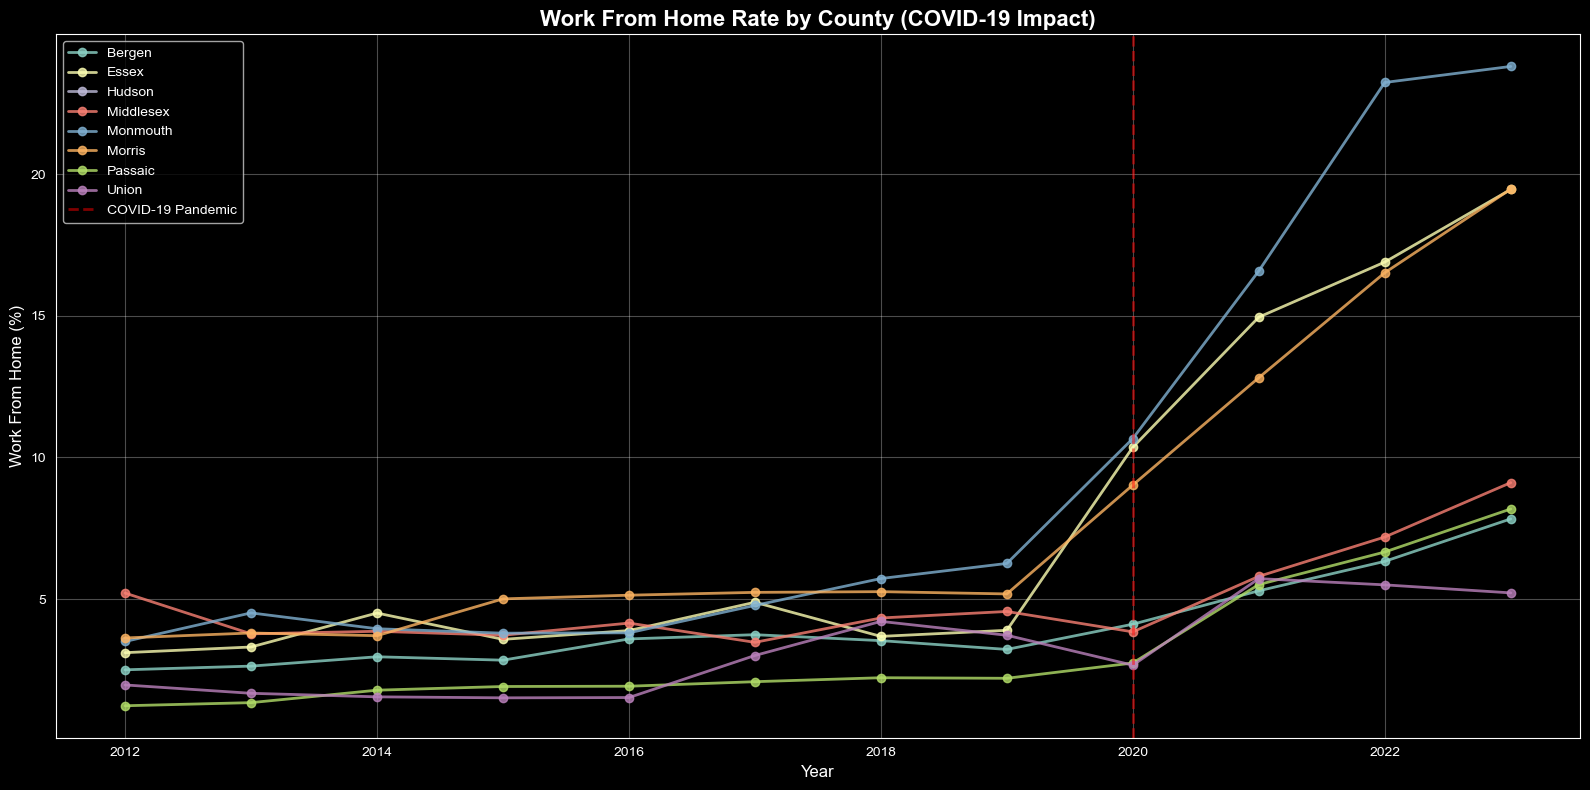

In [16]:
# Work From Home Trends (Pandemic Impact)
fig, ax = plt.subplots(figsize=(16, 8))

for county in major_counties:
    county_data = county_df[county_df['county'] == county]
    ax.plot(county_data['acs_year'], county_data['pct_wfh'], 
            marker='o', linewidth=2, label=county, alpha=0.8)

# Add vertical line for COVID-19 pandemic
if 2020 in county_df['acs_year'].values:
    ax.axvline(x=2020, color='red', linestyle='--', linewidth=2, alpha=0.5, label='COVID-19 Pandemic')

ax.set_title('Work From Home Rate by County (COVID-19 Impact)', fontsize=16, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Work From Home (%)', fontsize=12)
ax.legend(loc='best', fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Year-over-Year Growth Rates

In [20]:
# Calculate year-over-year changes for state-level metrics
state_growth = state_df.copy()
state_growth['pop_growth_pct'] = state_growth['pop_total'].pct_change() * 100
state_growth['income_growth_pct'] = state_growth['income_median_hh'].pct_change() * 100
state_growth['home_value_growth_pct'] = state_growth['home_value_median'].pct_change() * 100
state_growth['rent_growth_pct'] = state_growth['gross_rent_median'].pct_change() * 100

# Display growth rates
print("Year-over-Year Growth Rates (State Level):")
print(state_growth[['acs_year', 'pop_growth_pct', 'income_growth_pct', 'home_value_growth_pct', 'rent_growth_pct']].tail(5))

Year-over-Year Growth Rates (State Level):
    acs_year  pop_growth_pct  income_growth_pct  home_value_growth_pct  \
7       2019       -0.005124           5.525320               2.633333   
8       2020        8.922280           6.222381               3.101656   
9       2021        4.154278           4.637420               4.378642   
10      2022        0.131884           7.078904              11.981289   
11      2023        0.072276           3.768596               6.683735   

    rent_growth_pct  
7          3.563556  
8          1.809152  
9          5.609756  
10         9.336853  
11         3.439952  


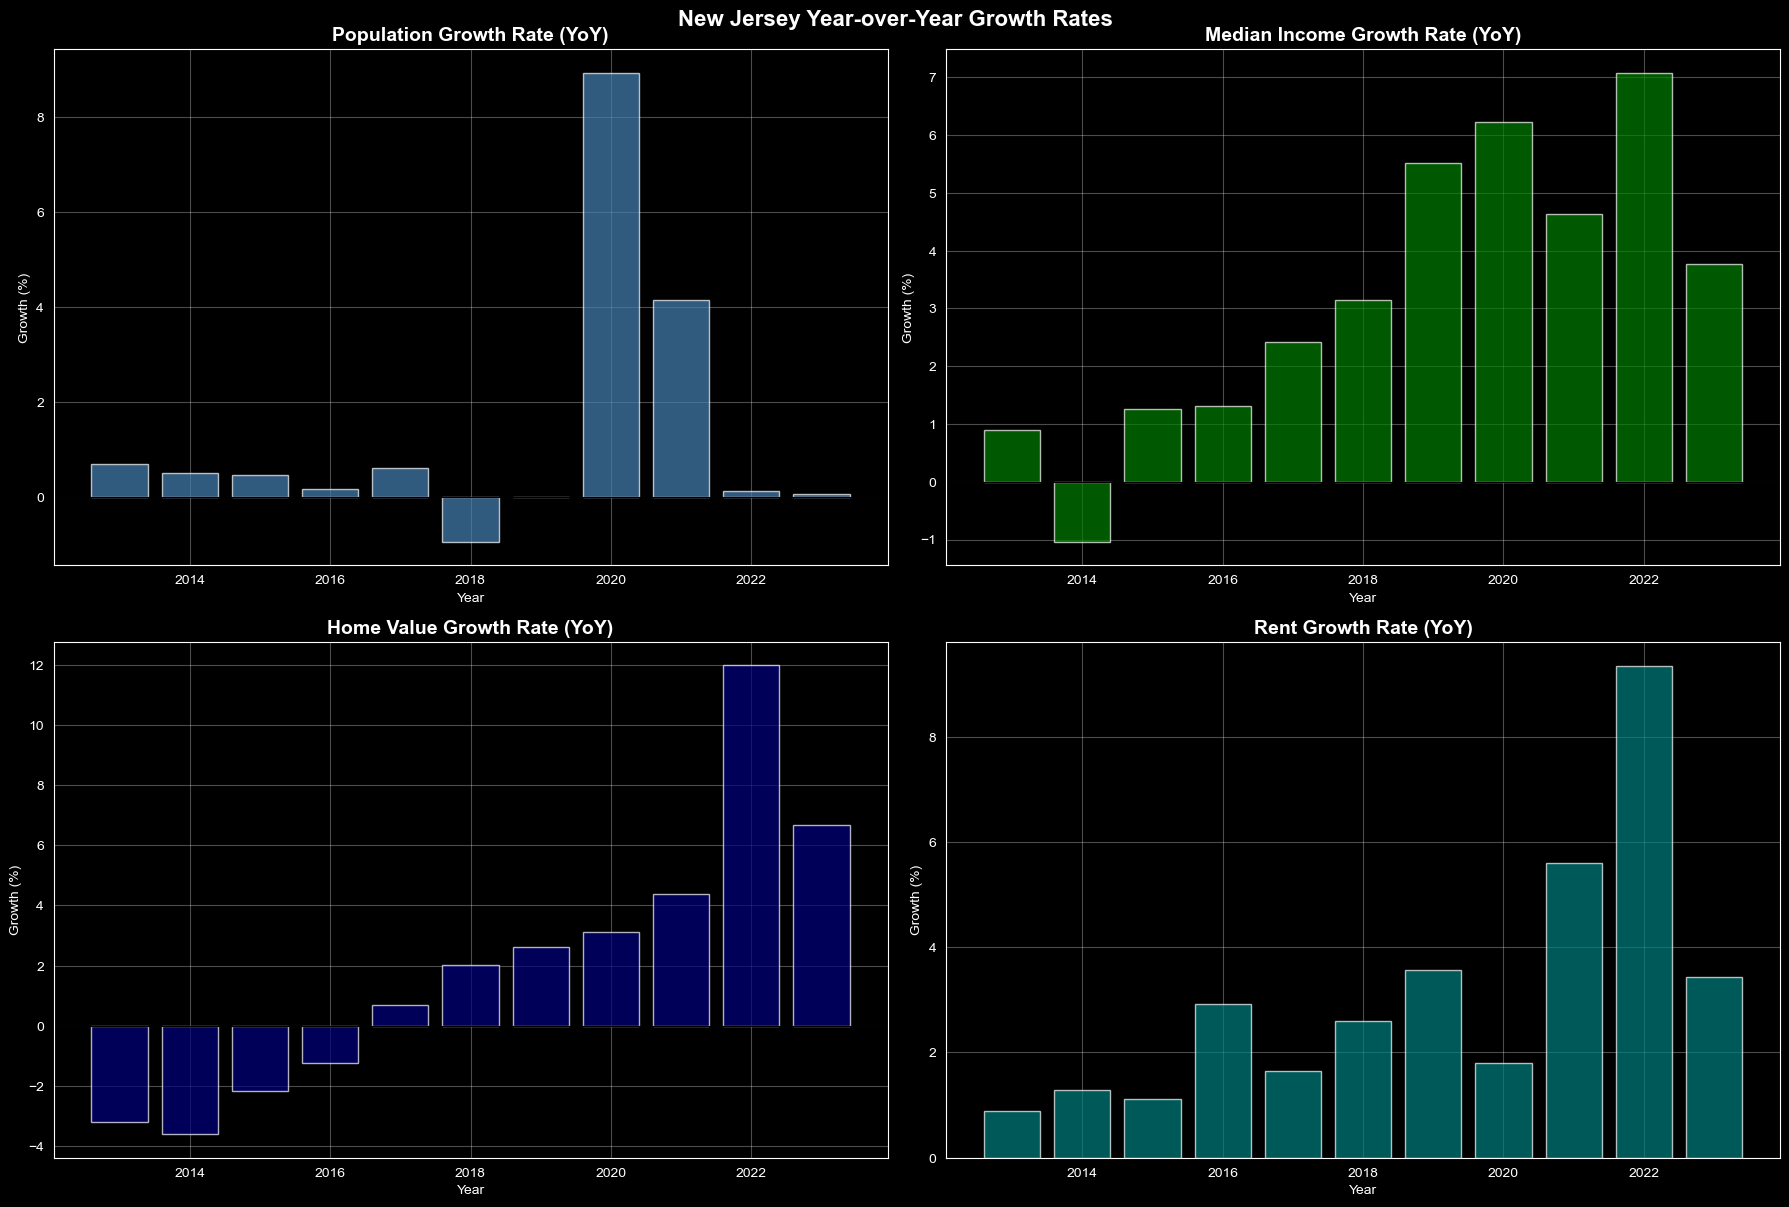

In [21]:
# Visualize Growth Rates
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Population Growth
axes[0, 0].bar(state_growth['acs_year'][1:], state_growth['pop_growth_pct'][1:], color='steelblue', alpha=0.7)
axes[0, 0].axhline(y=0, color='black', linestyle='-', linewidth=0.8)
axes[0, 0].set_title('Population Growth Rate (YoY)', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Year')
axes[0, 0].set_ylabel('Growth (%)')
axes[0, 0].grid(alpha=0.3)

# Income Growth
axes[0, 1].bar(state_growth['acs_year'][1:], state_growth['income_growth_pct'][1:], color='green', alpha=0.7)
axes[0, 1].axhline(y=0, color='black', linestyle='-', linewidth=0.8)
axes[0, 1].set_title('Median Income Growth Rate (YoY)', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Year')
axes[0, 1].set_ylabel('Growth (%)')
axes[0, 1].grid(alpha=0.3)

# Home Value Growth
axes[1, 0].bar(state_growth['acs_year'][1:], state_growth['home_value_growth_pct'][1:], color='navy', alpha=0.7)
axes[1, 0].axhline(y=0, color='black', linestyle='-', linewidth=0.8)
axes[1, 0].set_title('Home Value Growth Rate (YoY)', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Year')
axes[1, 0].set_ylabel('Growth (%)')
axes[1, 0].grid(alpha=0.3)

# Rent Growth
axes[1, 1].bar(state_growth['acs_year'][1:], state_growth['rent_growth_pct'][1:], color='teal', alpha=0.7)
axes[1, 1].axhline(y=0, color='black', linestyle='-', linewidth=0.8)
axes[1, 1].set_title('Rent Growth Rate (YoY)', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Year')
axes[1, 1].set_ylabel('Growth (%)')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.suptitle('New Jersey Year-over-Year Growth Rates', fontsize=16, fontweight='bold', y=1.002)
plt.show()

## 4. Summary Statistics

In [19]:
# Summary: Compare 2012 vs 2023 (first vs last year)
first_year = state_df['acs_year'].min()
last_year = state_df['acs_year'].max()

comparison = pd.DataFrame({
    'Metric': ['Population', 'Median Age', 'Median Income ($)', 'Poverty Rate (%)', 
               'Home Value ($)', 'Rent ($/mo)', 'Homeownership (%)', "Bachelor's+ (%)",
               'Unemployment (%)', 'Work From Home (%)', 'Diversity Index'],
    f'{first_year}': [
        f"{state_df[state_df['acs_year']==first_year]['pop_total'].values[0]:,.0f}",
        f"{state_df[state_df['acs_year']==first_year]['age_median'].values[0]:.1f}",
        f"${state_df[state_df['acs_year']==first_year]['income_median_hh'].values[0]:,.0f}",
        f"{state_df[state_df['acs_year']==first_year]['poverty_rate'].values[0]:.1f}",
        f"${state_df[state_df['acs_year']==first_year]['home_value_median'].values[0]:,.0f}",
        f"${state_df[state_df['acs_year']==first_year]['gross_rent_median'].values[0]:,.0f}",
        f"{state_df[state_df['acs_year']==first_year]['homeownership_rate'].values[0]:.1f}",
        f"{state_df[state_df['acs_year']==first_year]['pct_bachelors_plus'].values[0]:.1f}",
        f"{state_df[state_df['acs_year']==first_year]['unemployment_rate_acs'].values[0]:.1f}",
        f"{state_df[state_df['acs_year']==first_year]['pct_wfh'].values[0]:.1f}",
        f"{state_df[state_df['acs_year']==first_year]['diversity_index'].values[0]:.3f}",
    ],
    f'{last_year}': [
        f"{state_df[state_df['acs_year']==last_year]['pop_total'].values[0]:,.0f}",
        f"{state_df[state_df['acs_year']==last_year]['age_median'].values[0]:.1f}",
        f"${state_df[state_df['acs_year']==last_year]['income_median_hh'].values[0]:,.0f}",
        f"{state_df[state_df['acs_year']==last_year]['poverty_rate'].values[0]:.1f}",
        f"${state_df[state_df['acs_year']==last_year]['home_value_median'].values[0]:,.0f}",
        f"${state_df[state_df['acs_year']==last_year]['gross_rent_median'].values[0]:,.0f}",
        f"{state_df[state_df['acs_year']==last_year]['homeownership_rate'].values[0]:.1f}",
        f"{state_df[state_df['acs_year']==last_year]['pct_bachelors_plus'].values[0]:.1f}",
        f"{state_df[state_df['acs_year']==last_year]['unemployment_rate_acs'].values[0]:.1f}",
        f"{state_df[state_df['acs_year']==last_year]['pct_wfh'].values[0]:.1f}",
        f"{state_df[state_df['acs_year']==last_year]['diversity_index'].values[0]:.3f}",
    ]
})

print(f"\n{'='*70}")
print(f"NEW JERSEY: {first_year} vs {last_year} COMPARISON")
print(f"{'='*70}")
print(comparison.to_string(index=False))
print(f"{'='*70}\n")


NEW JERSEY: 2012 vs 2023 COMPARISON
            Metric      2012      2023
        Population 5,266,695 6,078,332
        Median Age      42.8      45.0
 Median Income ($)   $74,722  $105,363
  Poverty Rate (%)       7.7       7.6
    Home Value ($)  $323,900  $395,850
       Rent ($/mo)    $1,227    $1,714
 Homeownership (%)      73.5      75.1
   Bachelor's+ (%)      35.7      43.5
  Unemployment (%)       9.2       5.6
Work From Home (%)       4.2      14.2
   Diversity Index     0.249     0.355

